In [ ]:
import os
import sys

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
req_path = os.path.join(BASE_DIR, 'requirements.txt')

In [ ]:
!pip install -r "{req_path}"

In [ ]:
!pip install seaborn matplotlib pandas "numpy<2" scikit-learn tqdm ipywidgets 

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu --upgrade
!pip install transformers datasets accelerate --upgrade

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 1000)

%load_ext autoreload
%autoreload 2

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

try:
    from backend.config import DATA_DIR
    from models.aspect_extractor import KMeansAspectExtractor
    from models.absa_model import AspectSentimentAnalyzer
    from models.summary_model import ReviewSummarizer
    print(f"Окружение загружено. Директория данных: {DATA_DIR}")
except Exception as e:
    print(f"Ошибка загрузки модулей: {e}")

In [17]:
import logging
logging.disable(logging.CRITICAL)

# Исследование аналитического пайплайна для киноотзывов (Kinopoisk Analytics)

## 1. Постановка задачи и цели

В рамках проекта разрабатывается система для интеллектуальной обработки неструктурированных пользовательских рецензий на фильмы. Сырой текст содержит множество мнений, оценок и шума. 

Цели исследования:

1. Очистка текстов, извлечение числовых оценок и формирование пар "текст-вывод" для обучения генеративных моделей.
2. Динамическая кластеризация терминов для понимания, что именно обсуждают зрители (сюжет, графика, актеры).
3. Определение эмоциональной окраски по каждому выделенному аспекту фильма.
4. Генерация лаконичного вердикта на основе агрегированных рецензий с использованием архитектуры T5.

## 2. Анализ данных и предобработка

В процессе предобработки сырые текстовые файлы преобразуются в два структурированных датасета:

* Dataset 1 (Для ABSA): Содержит полные нормализованные тексты отзывов, тональность (метку папки) и извлеченную оценку пользователя.
* Dataset 2 (Для Саммаризации): Содержит только те отзывы, в которых алгоритм нашел маркеры вывода (например, "В итоге:"). Из них формируется пара: полный текст и сжатый вывод.

In [ ]:
import os

ds1_path = os.path.join(DATA_DIR, "dataset1.parquet")
ds2_path = os.path.join(DATA_DIR, "dataset2.parquet")

df1 = pd.read_parquet(ds1_path) if os.path.exists(ds1_path) else pd.DataFrame()
df2 = pd.read_parquet(ds2_path) if os.path.exists(ds2_path) else pd.DataFrame()

df1['review_len'] = df1['review_text'].str.len()

if not df2.empty:
    df2['text_len'] = df2['text'].str.len()
    df2['summary_len'] = df2['summary'].str.len()
    df2['compression_ratio'] = df2['text_len'] / df2['summary_len']

print("СТАТИСТИКА DATASET 1 (ABSA)")
print(f"Количество записей: {len(df1)}")
print(f"Средняя длина отзыва: {df1['review_len'].mean():.0f} символов")

valid_ratings = df1[df1['user_rating'] > 0]['user_rating']

print(f"Отзывов с явной оценкой: {len(valid_ratings)} (Средняя оценка: {valid_ratings.mean():.2f}/10)\n")

print("СТАТИСТИКА DATASET 2 (Саммаризация)")
print(f"Количество записей: {len(df2)}")

if not df2.empty:
    print(f"Средняя длина исходного текста: {df2['text_len'].mean():.0f} символов")
    print(f"Средняя длина вывода (summary): {df2['summary_len'].mean():.0f} символов")
    print(f"Средний коэффициент сжатия: {df2['compression_ratio'].mean():.1f}x\n")

print("ПРИМЕР ПАРЫ ТЕКСТ-САММАРИ ИЗ DATASET 2")

if not df2.empty:
    sample_d2 = df2[df2['text_len'] > 300].head(3)
    display(sample_d2[['text', 'text_len', 'summary', 'summary_len']])

СТАТИСТИКА DATASET 1 (ABSA)
Количество записей: 131669
Средняя длина отзыва: 2253 символов
Отзывов с явной оценкой: 86388 (Средняя оценка: 11575681815.22/10)

СТАТИСТИКА DATASET 2 (Саммаризация)
Количество записей: 24994
Средняя длина исходного текста: 2884 символов
Средняя длина вывода (summary): 1107 символов
Средний коэффициент сжатия: 7.6x

ПРИМЕР ПАРЫ ТЕКСТ-САММАРИ ИЗ DATASET 2


,text,text_len,summary,summary_len
0,"Страны-производители — Великобритания, Германия, США — сделали фильм-индульгенцию по после военным временам. Германия после Второй мировой войны разрушена, и вот британский военный Льюис Морган с женой селятся в особняке немца. Сразу встаёт вопрос комфорта или нет. Что чувствовать британке, пережившей бомбардировки Лондона, в окружении немцев? Льюис Морган (его играет Джейсон Кларк) комендант, но у него есть призраки прошлого, которые не дают ему с женой покоя. Фильм очень скучный. Актриса Кира Найтли играет скучающую жену Моргана. Фильм ставит кардинальный вопрос: «Могут ли британцы после пережитого в войне полюбить немцев?» Любовь к немцам и зона комфорта — насколько влияют друг на друга? Актёр Александр Скарсгард играет рокового соблазнителя. Но почему сегодня такие фильмы появляются на свет? Этот фильм ностальгирует и впадает в индульгенцию по поводу результатов Второй мировой войны. Фильм скучный, потому что говорит: «Все фашисты любили классическую музыку. И что музыка может ...",1810,"«Появился этот фильм-индульгенция». Зона комфорта между бывшими врагами где может проходить? Комфорт для английского коменданта, и комфорт для немецкого архитектора — на чём они стоят? Зона комфорта расширяется к бывшим врагам. Поэтому любовь между врагами уже возможна в кино 21-го века. Музыка в фильме очень скучна, как-будто это нравоучение о похоти для бывших врагов. 5 из 10",380
1,"Очередная моя рецензия на фильм, там где скорее всего больше никаких рецензий никогда не будет, да и никто её больше не прочитает. И вот я по своему обычаю решил выделиться на всеми забытом фильме, который нафиг никому не нужен. А началось всё с того, что я подсел на фильмы о вьетнамской войне и решил пересмотреть все более или менее имеющиеся в наличие и доступности. Перемолотил я их не мало и всякое повидал, от работ Уве Болла 'Туннельные крысы' до типичной всеми известной классики типа 'Взвод' и 'Цельнометаллическая оболочка', вообщем все, что были сняты на этом бренном мире, вплоть до самый неизвестных, включая и этот. И начну с того, что конкретно данный фильм снят совсем недавно, в 2018 году, а то есть он отражает сегодняшнее настроение и обстановку в США, ведь многое поменялось за то время, когда был снят последний нормальный фильм про эту войну. Так что же не так спросите вы меня, что могло меня так возмутить на такое количество букв? Эффекты плохие..? Игра актеров и постан...",3723,"Смотреть строго не рекомендую. Фильм ужасен по всем параметрам, начиная от эффектов и постановки, заканчивая сценарием и актерами. Спасибо за внимания. Критика всего и вся приветствуется.",187
2,"Фильм про влияние деятельности человека на климат, а также про меры, которые «защитники» природы предлагают предпринять для спасения планеты: ) Главный «спаситель» - Леонардо ДиКаприо. Он выступает в роли интервьюера, т.е. по ходу фильма берёт интервью у разнообразных забавных и не очень персонажей. Честно говоря, «шедевр» мне не понравился. По моему мнению фильм не документальный, как заявлено, а пропагандистский. Он имеет своей целью навязать публике строго определённую точку зрения. Я считаю, что ДиКаприо, как интервьюер, должен был показать мнения разных сторон, привести их доказательства, а делать выводы и решать, что правдивее зритель может и самостоятельно. Вот в фильме ДиКаприо говорит про факты. Но где эти факты? То, что создатели фильма «Выживший» не могут найти снег для съёмок – это не научный факт, это обычная реклама фильма «Выживший»... Также в фильме ДиКаприо говорит, что противники теории глобального потепления куплены и лоббируют интересы корпорации, добывающих угл...",1675,"планету от глобального потепления – это бред. Ну какая разница для атмосферы, что Вы пересели на электромобиль? Ведь для того, чтобы сгенерировать электроэнергию для зарядки электромобиля, всё равно надо сжечь на электростанции углеводороды... В общем и целом, фильм интересный с художественной точки зрения, но он не является документальным...",344


## 3. Генерация и извлечение аспектов (Word2Vec + KMeans)

Вместо жестко заданного словаря аспектов, пайплайн выявляет их динамически, основываясь на контексте отзывов к конкретному фильму.

Механика работы:

### Векторизация (Word2Vec)

Модель трансформирует слова в плотные векторы фиксированной размерности (например, 300), где семантически близкие слова находятся рядом в векторном пространстве.

### Лемматизация
   
Каждое слово приводится к нормальной форме (отсекаются суффиксы и окончания), удаляются стоп-слова.

### Кластеризация (Seeded K-Means)
   
Из текста извлекаются уникальные леммы-кандидаты. Алгоритм K-Means разбивает их на $N$ кластеров. Для стабилизации кластеров в качестве начальных центроид (seed) используются эмбеддинги якорных слов (сюжет, каст, визуал).

### Метрика близости

Для выбора названия аспекта ищутся слова из заранее заданного словаря кинокритики, векторы которых имеют минимальное евклидово расстояние до центра кластера:
$$d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$$

In [ ]:
extractor = KMeansAspectExtractor(n_clusters=4)

print("ПРИМЕР РАБОТЫ WORD2VEC")

try:
    similar_words = extractor.word2vec_model.wv.most_similar("сюжет", topn=7)
    print("Слова, семантически близкие к 'сюжет':")

    for word, score in similar_words:
        print(f" - {word} (Сходство: {score:.3f})")
except Exception as e:
    print(f"Ошибка Word2Vec: {e}")

print("\nИЗВЛЕЧЕНИЕ АСПЕКТОВ ДЛЯ ФИЛЬМА")

target_movie = "433210"
movie_df = df1[df1['movie_id'] == target_movie]

if movie_df.empty:
    print(f"Фильм ID {target_movie} не найден в выборке. Используем 20 случайных длинных отзывов.")
    movie_df = df1[df1['review_len'] > 500].sample(20, random_state=42)

texts_to_extract = movie_df['review_text'].tolist()

print(f"Количество отзывов для анализа: {len(texts_to_extract)}")
print(f"Пример отзыва:\n{texts_to_extract[0][:400]}...\n")

generated_aspects = extractor.fit_predict(texts_to_extract)

ПРИМЕР РАБОТЫ WORD2VEC
Слова, семантически близкие к 'сюжет':
 - сюжетн (Сходство: 0.607)
 - сюжетный (Сходство: 0.571)
 - сценарий (Сходство: 0.569)
 - сюжетных (Сходство: 0.561)
 - сюжетны (Сходство: 0.527)
 - сюжетец (Сходство: 0.524)
 - сюжетным (Сходство: 0.523)

ИЗВЛЕЧЕНИЕ АСПЕКТОВ ДЛЯ ФИЛЬМА
Количество отзывов для анализа: 100
Пример отзыва:
Если и существуют фильмы, за просмотром которых вжимаешься в кресло, а после проводишь неделю в попытках изменить свою жизнь к лучшему, то 'Чат' к числу подобных кинокартин не относится. 'Интернет опасен'. Во время просмотра никак не давала покоя мысль о том, что создатели фильма ни о чем больше и не хотели до зрителя донести. 'Если Вы по Интернету мчитесь, словно угорелый, А навстречу Вам из чата...



## 4. Аспектно-ориентированный анализ тональности (ABSA)

Получив список аспектов (например: *сюжет, визуал, каст*), необходимо понять, в каком ключе они упоминаются. 

### Архитектура пайплайна (**BiLSTM**)

1. Текст разбивается на предложения.
2. Считается косинусное сходство (**Cosine Similarity**) между вектором предложения и вектором каждого аспекта. Если сходство превышает порог `SIMILARITY_THRESHOLD`, считается, что предложение относится к этому аспекту.
$$\text{Cosine Sim} = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\|\|\mathbf{B}\|}$$
3. Вектор предложения подается в двунаправленную рекуррентную нейросеть (**BiLSTM**). Она учитывает контекст слова как слева направо, так и справа налево.
4. Выход сети пропускается через полносвязный слой и функцию Softmax для предсказания вероятности трех классов (*Негатив, Нейтрально, Позитив*):
$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}$$

### Метрики качества классификации

Оценка модели производится по стандартным метрикам:

* Precision (Точность)
* Recall (Полнота)
* F1-Score (Гармоническое среднее)

In [ ]:
absa = AspectSentimentAnalyzer(load_weights=True)

print(f"Анализ отзывов по выделенным аспектам: {generated_aspects}")
aspect_scores = absa.predict(texts_to_extract, generated_aspects)

print("\nРЕЗУЛЬТАТЫ ABSA")

for aspect, stats in aspect_scores.items():
    total = stats['mentions']

    if total > 0:
        print(f"Аспект '{aspect.upper()}' (Упоминаний: {total}):")
        print(f"  Позитив: {stats['pos']}% | Негатив: {stats['neg']}% | Нейтрально: {stats['neu']}%")
        
        pos_bar = "█" * int(stats['pos'] / 5)
        neg_bar = "█" * int(stats['neg'] / 5)
        
        print(f"  [+] {pos_bar}")
        print(f"  [-] {neg_bar}\n")

Анализ отзывов по выделенным аспектам: ['визуал', 'каст', 'антагонист', 'фильм']

РЕЗУЛЬТАТЫ ABSA
Аспект 'ВИЗУАЛ' (Упоминаний: 28):
  Позитив: 46.4% | Негатив: 14.3% | Нейтрально: 39.3%
  [+] █████████
  [-] ██

Аспект 'КАСТ' (Упоминаний: 12):
  Позитив: 25.0% | Негатив: 8.3% | Нейтрально: 66.7%
  [+] █████
  [-] █

Аспект 'АНТАГОНИСТ' (Упоминаний: 7):
  Позитив: 28.6% | Негатив: 28.6% | Нейтрально: 42.9%
  [+] █████
  [-] █████

Аспект 'ФИЛЬМ' (Упоминаний: 296):
  Позитив: 31.4% | Негатив: 18.2% | Нейтрально: 50.3%
  [+] ██████
  [-] ███



## 5. Автоматическая суммаризация (T5)

Задача суммаризации заключается в компрессии множества мнений в единый короткий текст. В проекте используется архитектура **Transformer**, а именно модель `rut5_base_sum_gazeta` от Ильи Гусева.

### Обучение и метрики

Базовая модель была обучена на новостном корпусе ([Gazeta.ru](https://huggingface.co/datasets/IlyaGusev/gazeta)) для выделения главных фактов из статей. Для текущей задачи (киноотзывы) был проведен файнтюнинг на `dataset2.parquet`. Модель оптимизировалась с использованием **Cross-Entropy Loss**, пытаясь сгенерировать токены, максимально совпадающие с эталонными выводами пользователей.

Качество генеративных моделей обычно оценивается метрикой **ROUGE** (Recall-Oriented Understudy for Gisting Evaluation), которая считает перекрытие n-грамм:
$$\text{ROUGE-N} = \frac{\sum_{\text{Match}} \text{N-grams}}{\sum_{\text{Reference}} \text{N-grams}}$$
В данном случае используются параметры `no_repeat_ngram_size=3` и `repetition_penalty` для защиты от зацикливания генерации.

In [ ]:
from models.summary_model import ReviewSummarizer

summarizer = ReviewSummarizer(load_weights=True)

texts_to_summarize = texts_to_extract[:30]

print(f"Суммаризация {len(texts_to_summarize)} отзывов...\n")

print("ИСХОДНЫЕ ДАННЫЕ ДЛЯ СУММАРИЗАЦИИ\n")
print(f"Всего отзывов: {len(texts_to_summarize)}")

lengths = [len(t.split()) for t in texts_to_summarize]

print(f"Длина отзывов (в словах): мин={min(lengths)}, макс={max(lengths)}, средняя={sum(lengths)/len(lengths):.1f}")

print("\nПервые 3 отзыва (для ознакомления):")

for i, text in enumerate(texts_to_summarize[:3], 1):
    print(f"\nОтзыв {i}")
    print(text[:500] + "..." if len(text) > 500 else text)

summary_text = summarizer.generate(texts_to_summarize)

print("\nСГЕНЕРИРОВАННЫЙ ВЕРДИКТ")
print(summary_text)

Loading weights: 100%|██████████| 284/284 [00:00<00:00, 29866.92it/s]


Суммаризация 30 отзывов...

ИСХОДНЫЕ ДАННЫЕ ДЛЯ СУММАРИЗАЦИИ

Всего отзывов: 30
Длина отзывов (в словах): мин=155, макс=722, средняя=343.7

Первые 3 отзыва (для ознакомления):

Отзыв 1
Если и существуют фильмы, за просмотром которых вжимаешься в кресло, а после проводишь неделю в попытках изменить свою жизнь к лучшему, то 'Чат' к числу подобных кинокартин не относится. 'Интернет опасен'. Во время просмотра никак не давала покоя мысль о том, что создатели фильма ни о чем больше и не хотели до зрителя донести. 'Если Вы по Интернету мчитесь, словно угорелый, А навстречу Вам из чата вышел Уильям погулять, Не сворачивайте аську. В аське добрый Мо и Эва. Укокошьте, лучше, Уилла. Уил...

Отзыв 2
Пытался вспомнить хоть один стоящий фильм, посвященный теме интернета и всего с ним связанного (хакеры, вирусы, виртуальность). И не смог. Начиная с «Социальной сети» Финчера и заканчивая слабенькими бледненькими глупенькими потугами сериалов типа «Мистер робот» и «Чёрное зеркало» - из всего выходит п

## 6. Визуализация и общие выводы

Для корректной работы моделей критически важно понимать структуру обучающих данных. Ниже приведены графики распределения ключевых характеристик датасета. В частности, из распределения оценок исключены "нулевые" значения (отсутствующие оценки), чтобы получить объективную картину зрительских симпатий.

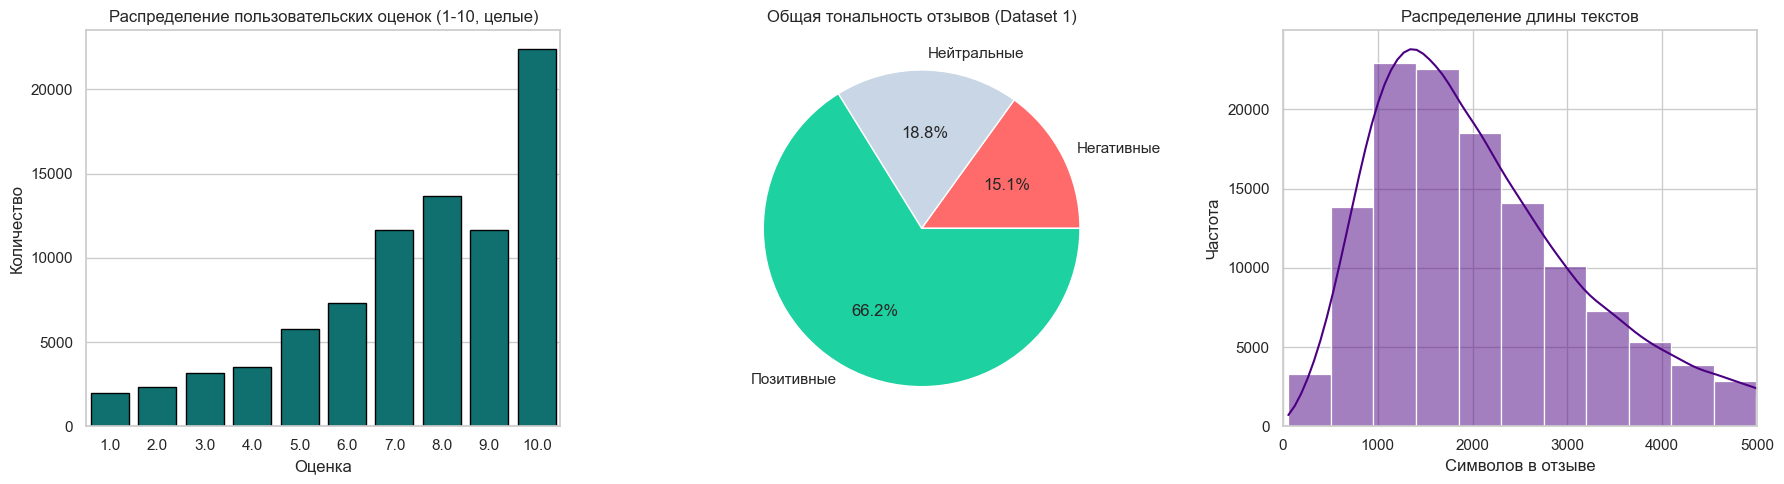

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

valid_ratings = df1[
    (df1['user_rating'] >= 1) & 
    (df1['user_rating'] <= 10) & 
    (df1['user_rating'] == df1['user_rating'].astype(int))
]['user_rating']

sns.countplot(x=valid_ratings, ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Распределение пользовательских оценок (1-10, целые)')
axes[0].set_xlabel('Оценка')
axes[0].set_ylabel('Количество')

if 'sentiment' in df1.columns:
    sentiment_counts = df1['sentiment'].value_counts().sort_index()
    axes[1].pie(sentiment_counts, labels=['Негативные', 'Нейтральные', 'Позитивные'], autopct='%1.1f%%', colors=['#ff6b6b', '#c8d6e5', '#1dd1a1'])
    axes[1].set_title('Общая тональность отзывов (Dataset 1)')

sns.histplot(df1['review_len'], bins=30, ax=axes[2], color='indigo', kde=True)
axes[2].set_xlim(0, 5000)
axes[2].set_title('Распределение длины текстов')
axes[2].set_xlabel('Символов в отзыве')
axes[2].set_ylabel('Частота')

plt.tight_layout()
plt.show()